# Student Performance — Exploratory Data Analysis

**Author:** Nguyen Doan Duy Khoa
**Dataset:** `Student_Performance_1k.csv` (1,000 student records)


## 1. Project Overview

This project explores a dataset of 1,000 students to understand which study-related and
lifestyle factors are associated with academic performance. The analysis covers data quality
checks, univariate distributions, and bivariate relationships between study habits, sleep,
extracurricular activity, gender, and the final **Performance Index**.

The goal is to demonstrate a complete, evidence-based EDA workflow: profiling the data,
cleaning it, and then using descriptive statistics and visualizations to answer concrete
analytical questions rather than simply describing chart shapes.


## 2. Objectives / Analytical Questions

1. How complete and clean is the dataset (missing values, duplicates, outliers)?
2. How are key numeric variables distributed (e.g., `Previous Scores`)?
3. Is there a relationship between `Previous Scores` and the final `Performance Index`?
4. Does participation in extracurricular activities relate to `Performance Index` or to `Gender`?
5. Which variables in the dataset show the strongest relationship with `Performance Index` overall?


## 3. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

## 4. Dataset Overview

In [2]:
data = pd.read_csv('Student_Performance_1k_dataset.csv')
data.head()


,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index,Gender
0,5,73,Yes,9,3,60,Female
1,3,75,Yes,5,9,57,Male
2,1,82,No,8,7,58,Male
3,1,82,No,8,7,58,Male
4,3,62,No,5,1,43,Female


### 4.1 Column types and cardinality

Before cleaning, it is useful to separate categorical (`object`) columns from numeric columns
and check how many unique values and non-null entries each one has. This gives a quick sense of
which columns are categorical vs. continuous, and flags any columns that might need attention.


In [3]:
# Identify 'object' (categorical) columns and their number of unique values
object_columns = list(data.select_dtypes(['object']).columns)
object_columns

['Extracurricular Activities', 'Gender']

In [4]:
# Count unique values and non-null rate for each categorical column
for column in object_columns:
    print("* Column:", column)
    print(len(data[column].unique()), "unique values", "\t & \t",
          data[column].notnull().sum(), "non-null values\t",
          round(100 * data[column].notnull().sum() / len(data[column]), 2), "% non-null")

* Column: Extracurricular Activities
3 unique values 	 & 	 997 non-null values	 99.7 % non-null
* Column: Gender
2 unique values 	 & 	 1000 non-null values	 100.0 % non-null


In [5]:
# List of numeric columns
numeric_columns = list(data.select_dtypes(['number']).columns)
numeric_columns

['Hours Studied',
 'Previous Scores',
 'Sleep Hours',
 'Sample Question Papers Practiced',
 'Performance Index']

In [6]:
# Count unique values and non-null rate for each numeric column
for column in numeric_columns:
    print("* Column:", column)
    print(len(data[column].unique()), "unique values", "\t & \t",
          data[column].notnull().sum(), "non-null values\t",
          round(100 * data[column].notnull().sum() / len(data[column]), 2), "% non-null")

* Column: Hours Studied
9 unique values 	 & 	 1000 non-null values	 100.0 % non-null
* Column: Previous Scores
61 unique values 	 & 	 1000 non-null values	 100.0 % non-null
* Column: Sleep Hours
8 unique values 	 & 	 1000 non-null values	 100.0 % non-null
* Column: Sample Question Papers Practiced
10 unique values 	 & 	 1000 non-null values	 100.0 % non-null
* Column: Performance Index
87 unique values 	 & 	 1000 non-null values	 100.0 % non-null


**Observation:** the dataset has one categorical column of real interest,
`Extracurricular Activities` (Yes/No), and `Gender` (Female/Male). All other columns are
numeric (`Hours Studied`, `Previous Scores`, `Sleep Hours`, `Sample Question Papers Practiced`,
`Performance Index`). Both categorical columns are close to 100% non-null, which is confirmed
more precisely in the missing-value check below.


## 5. Data Cleaning and Preparation

### 5.1 Duplicate records

Exact duplicate rows can silently inflate counts and bias summary statistics, so they are
checked and removed before any further analysis.


In [7]:
data.duplicated().sum()

np.int64(2)

In [8]:
data[data.duplicated()]

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index,Gender
3,1,82,No,8,7,58,Male
136,5,70,Yes,8,0,58,Female


In [9]:
data[data.duplicated(keep=False)]

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index,Gender
2,1,82,No,8,7,58,Male
3,1,82,No,8,7,58,Male
135,5,70,Yes,8,0,58,Female
136,5,70,Yes,8,0,58,Female


In [10]:
# Remove duplicate rows
print("Before:", len(data))
data = data.drop_duplicates()
print("After:", len(data))

Before: 1000
After: 998


**Finding:** the raw dataset contains 2 fully duplicated rows (4 rows involved once both
copies are counted). These are removed, leaving 998 unique records.


### 5.2 Missing values

`Extracurricular Activities` is the only column with missing values (3 records, ~0.3% of the
data) — too small a share to justify dropping rows, so it is imputed instead.


In [11]:
data.isnull().sum()

Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          3
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
Gender                              0
dtype: int64

In [12]:
# 'Extracurricular Activities' has 3 missing values.
# Dropping the affected rows would be one option — check the impact:
print("Before:", len(data))
data_no_missing = data.dropna()
print("After:", len(data_no_missing))

Before: 998
After: 995


In [13]:
# Instead of dropping rows, inspect the distribution of the column to choose an imputation value
data['Extracurricular Activities'].describe()

count     995
unique      2
top        No
freq      517
Name: Extracurricular Activities, dtype: object

In [14]:
data['Extracurricular Activities'].describe().top

'No'

In [15]:
# Most frequent category (mode) of 'Extracurricular Activities'
mode_EA = data['Extracurricular Activities'].describe().top

In [16]:
# Impute the missing values with the mode
data['Extracurricular Activities'] = data['Extracurricular Activities'].fillna(mode_EA)

**Decision:** rather than dropping the 3 affected rows (which would only cost 0.3% of the
data but is unnecessary here), missing values in `Extracurricular Activities` are imputed with
the column's mode (`"No"`), which is the most defensible simple strategy for a binary
categorical variable with so few missing entries.


### 5.3 Outlier check on `Sleep Hours`

`Sleep Hours` is checked for outliers using the IQR (interquartile range) rule, a standard
approach for a roughly bounded, self-reported numeric variable like hours of sleep.


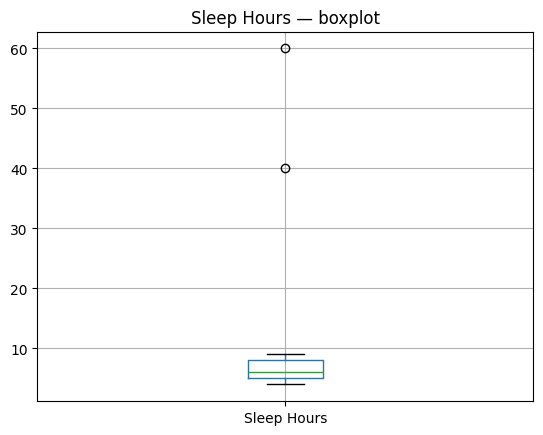

In [17]:
data.boxplot('Sleep Hours')
plt.title('Sleep Hours — boxplot')
plt.show()

In [18]:
Q1 = data['Sleep Hours'].quantile(0.25)
Q3 = data['Sleep Hours'].quantile(0.75)
IQR = Q3 - Q1
data = data[(Q1 - 1.5*IQR <= data['Sleep Hours']) & (data['Sleep Hours'] <= Q3 + 1.5*IQR)]  # remove outliers
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 996 entries, 0 to 999
Data columns (total 7 columns):
 #   Column                            Non-Null Count  Dtype 
---  ------                            --------------  ----- 
 0   Hours Studied                     996 non-null    int64 
 1   Previous Scores                   996 non-null    int64 
 2   Extracurricular Activities        996 non-null    object
 3   Sleep Hours                       996 non-null    int64 
 4   Sample Question Papers Practiced  996 non-null    int64 
 5   Performance Index                 996 non-null    int64 
 6   Gender                            996 non-null    object
dtypes: int64(5), object(2)
memory usage: 62.2+ KB


**Finding:** the IQR rule flags 2 records as outliers in `Sleep Hours`; removing them leaves
996 clean records for the analysis that follows.


## 6. Exploratory Data Analysis

### 6.1 Gender distribution

In [19]:
data['Gender'].value_counts()

Gender
Female    558
Male      438
Name: count, dtype: int64

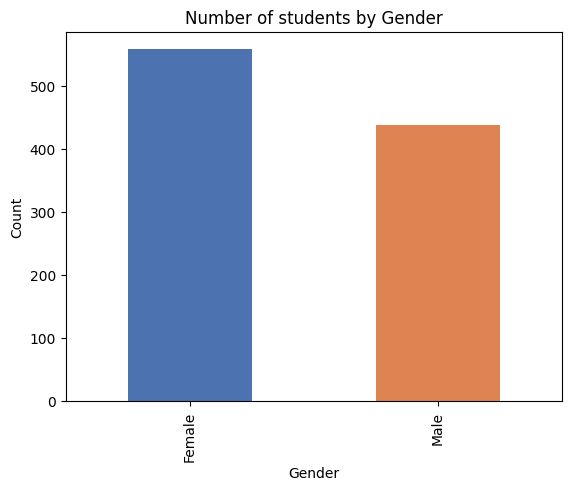

In [20]:
data['Gender'].value_counts().plot.bar(color=['#4C72B0', '#DD8452'])
plt.title('Number of students by Gender')
plt.ylabel('Count')
plt.show()

**Finding:** the sample is reasonably balanced by gender (558 female vs. 438 male students,
after cleaning), so gender-based comparisons elsewhere in the notebook are not distorted by a
heavily skewed split.


### 6.2 Distribution of `Previous Scores`

Skewness and kurtosis quantify the shape of the distribution: skewness measures asymmetry, and
(excess) kurtosis measures how heavy or light the tails are compared to a normal distribution.


In [21]:
stats.skew(data['Previous Scores'])  # close to 0 → roughly symmetric, very slight left skew

np.float64(-0.05742212179536348)

In [22]:
stats.kurtosis(data['Previous Scores'])  # negative → flatter than a normal distribution (platykurtic)

np.float64(-1.2099441917189186)

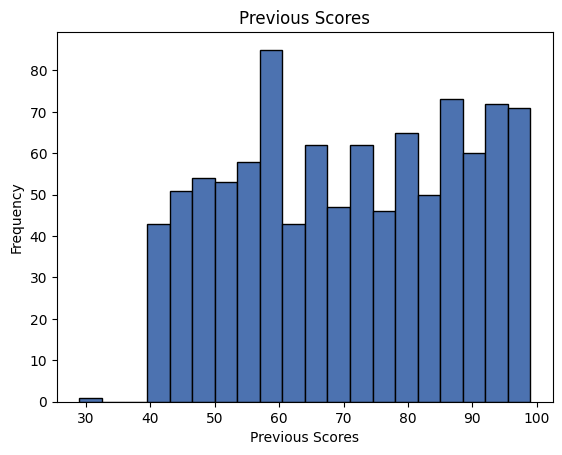

In [23]:
data.hist('Previous Scores', bins=20, color='#4C72B0', edgecolor='black', grid=False)
plt.xlabel('Previous Scores')
plt.ylabel('Frequency')
plt.show()

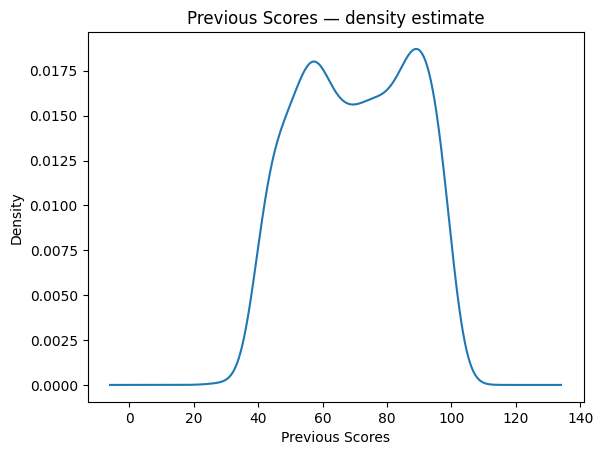

In [24]:
data['Previous Scores'].plot.kde()
plt.title('Previous Scores — density estimate')
plt.xlabel('Previous Scores')
plt.show()

**Finding:** skewness of about **-0.06** is essentially zero, meaning the distribution of
`Previous Scores` is close to symmetric (only a negligible left-leaning tendency). Kurtosis of
about **-1.21** is clearly negative, indicating a **platykurtic** (flatter-than-normal)
distribution — scores are spread fairly evenly across the range rather than concentrated around
the mean, which the histogram and KDE plot both confirm.


### 6.3 Relationship between `Previous Scores` and `Performance Index`


In [25]:
data[['Previous Scores', 'Performance Index']].corr()

,Previous Scores,Performance Index
Previous Scores,1.000000,0.918067
Performance Index,0.918067,1.000000


**Finding:** `Previous Scores` and `Performance Index` are strongly, positively correlated
(Pearson r ≈ **0.92**). Students who scored higher on previous assessments tend to also reach a
higher final Performance Index, which is an expected and intuitive result — prior academic
performance is a strong predictor of later performance.


### 6.4 Extending the correlation analysis to all numeric variables *(added analysis)*

The original analysis compared only `Previous Scores` against `Performance Index`. Since the
dataset has several other numeric variables (`Hours Studied`, `Sleep Hours`,
`Sample Question Papers Practiced`), it is worth checking how each of them relates to the target
variable, `Performance Index`, in one view.


In [26]:
corr_with_target = data.select_dtypes('number').corr()['Performance Index'].sort_values(ascending=False)
corr_with_target

Performance Index                   1.000000
Previous Scores                     0.918067
Hours Studied                       0.427000
Sleep Hours                         0.020409
Sample Question Papers Practiced    0.005141
Name: Performance Index, dtype: float64

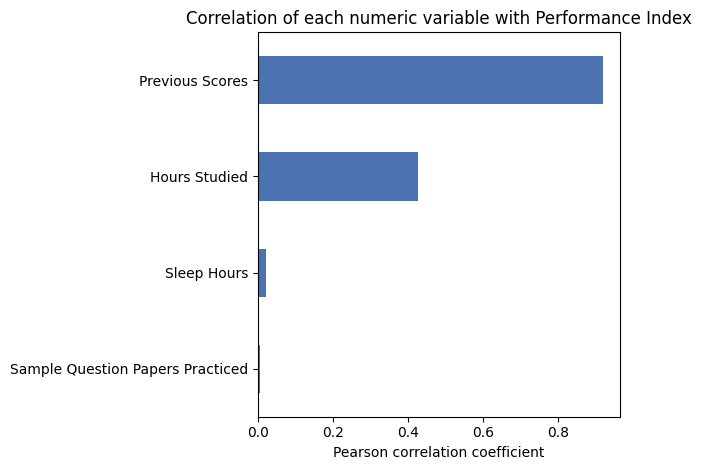

In [27]:
corr_with_target.drop('Performance Index').plot(kind='barh', color='#4C72B0')
plt.title('Correlation of each numeric variable with Performance Index')
plt.xlabel('Pearson correlation coefficient')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**Finding:** beyond `Previous Scores` (r ≈ 0.92), `Hours Studied` also shows a moderate
positive relationship with `Performance Index` (r ≈ **0.43**), which is a plausible, actionable
signal — more study time is associated with better outcomes, though far less strongly than prior
performance. `Sleep Hours` (r ≈ 0.02) and `Sample Question Papers Practiced` (r ≈ 0.01) show
almost no linear relationship with the final index in this dataset, at least on their own.


### 6.5 `Extracurricular Activities` vs. `Gender`

This checks whether participation in extracurricular activities differs by gender.


In [28]:
table = pd.crosstab(data['Extracurricular Activities'], data['Gender'])
table

Gender,Female,Male
Extracurricular Activities,,
No,287,232
Yes,271,206


In [29]:
table = pd.crosstab(data['Extracurricular Activities'], data['Gender'], normalize=True)
table

Gender,Female,Male
Extracurricular Activities,,
No,0.288153,0.232932
Yes,0.272088,0.206827


In [30]:
table_normalized = table.div(table.sum(axis=1), axis=0)
table_normalized

Gender,Female,Male
Extracurricular Activities,,
No,0.552987,0.447013
Yes,0.568134,0.431866


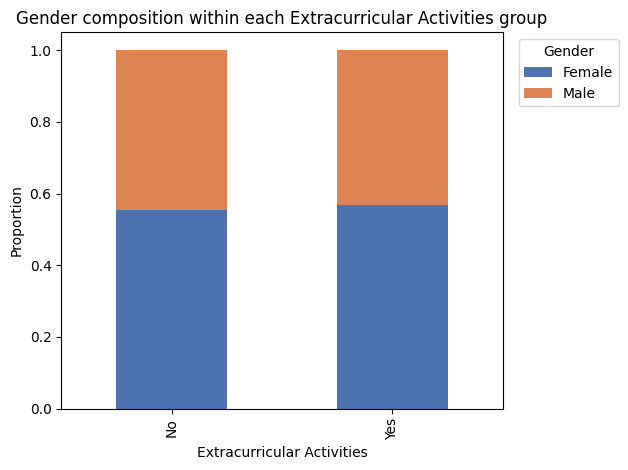

In [31]:
# Plot
table_normalized.plot(kind='bar', stacked=True, color=['#4C72B0', '#DD8452'])
plt.title('Gender composition within each Extracurricular Activities group')
plt.ylabel('Proportion')
plt.legend(title='Gender', bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

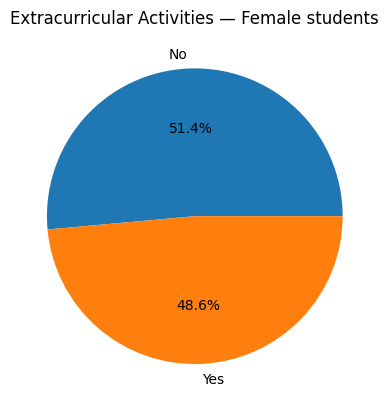

In [32]:
# Female
data_female = data[data['Gender'] == 'Female']
EA_counts = data_female['Extracurricular Activities'].value_counts()
EA_counts.plot(kind='pie', autopct='%1.1f%%', title='Extracurricular Activities — Female students')
plt.ylabel('')
plt.show()

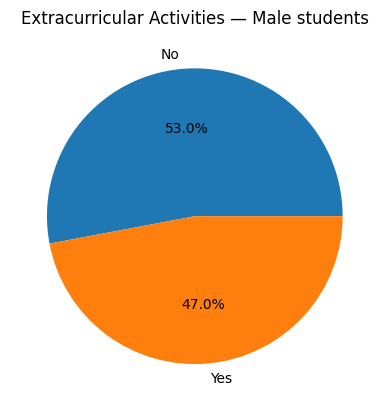

In [33]:
# Male
data_male = data[data['Gender'] == 'Male']
EA_counts = data_male['Extracurricular Activities'].value_counts()
EA_counts.plot(kind='pie', autopct='%1.1f%%', title='Extracurricular Activities — Male students')
plt.ylabel('')
plt.show()

**Finding:** the gender split within each `Extracurricular Activities` group is almost
identical (about 55% female / 45% male whether or not a student takes part in extracurricular
activities). This means participation in extracurricular activities is **not meaningfully
associated with gender** in this dataset — the two variables appear largely independent.


### 6.6 `Extracurricular Activities` vs. `Performance Index`


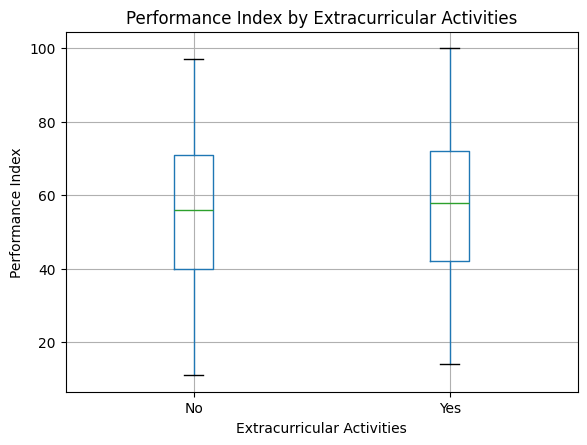

In [34]:
data.boxplot(column='Performance Index', by='Extracurricular Activities')
plt.title('Performance Index by Extracurricular Activities')
plt.suptitle('')
plt.ylabel('Performance Index')
plt.show()

**Finding:** students who participate in extracurricular activities have a slightly higher
average Performance Index (≈57.4) than those who do not (≈55.4), a difference of about 2 points
on the index. The two boxplots overlap substantially, so this gap is real but modest — on its
own, extracurricular participation is a much weaker signal for performance than `Previous Scores`
or `Hours Studied`.


## 7. Key Findings

- After removing 2 duplicate rows and 2 sleep-hours outliers, the working dataset covers 996
  clean student records, split roughly evenly by gender (56% female / 44% male).
- `Previous Scores` is the strongest predictor of `Performance Index` in this dataset
  (r ≈ 0.92), followed by `Hours Studied` (r ≈ 0.43). `Sleep Hours` and
  `Sample Question Papers Practiced` show almost no linear relationship with performance.
- `Previous Scores` is distributed close to symmetrically (skew ≈ -0.06) but flatter than a
  normal distribution (kurtosis ≈ -1.21), so scores are spread fairly evenly across the range.
- Extracurricular participation has only a marginal association with `Performance Index`
  (~2-point difference) and no meaningful association with `Gender`.


## 8. Conclusion and Recommendations

The data supports a clear, intuitive story: **past academic performance and study time are the
main drivers of the final Performance Index**, while lifestyle factors captured here (sleep,
extracurricular participation) and practice-paper volume show little to no independent
relationship with the outcome, at least in a simple linear sense. For a student-support context,
this suggests that interventions aimed at increasing effective study time are more likely to move
the needle than encouraging more practice papers or discouraging extracurricular involvement,
though this dataset cannot establish causation — only association.
